In [1]:
# Autoreload custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os

import pandas as pd
import json

import numpy as np
import jax
import jax.numpy as jnp
import optax

import time
import importlib
import matplotlib.pyplot as plt

In [3]:
# import custom modules
sys.path.append('..')

from models.models import DecoderOnlyTransformer
from util.data_loader import load_data, encode, decode, get_batch
from util.optimization import train_step, loss_and_metrics, create_train_state

In [ ]:
# initialize jax random key
master_key = jax.random.PRNGKey(0)

In [4]:
# load dataset
train_data, test_data, ctoi, itoc, vocab_size = load_data(encoded_path='../data/encoded.pkl')

#### Model

In [ ]:
# Model parameters
d_model = 256
n_heads = 4
n_layers = 4 # Based on model_arch experiment

# Training parameters
B, T = 128, 64
niter = 25000

Training function for tesing

In [ ]:
# Create a training function for testing different optimizers
def train_model(tx, master_key, niter=niter, label:str='optimizer'):
    # Initialize model
    key, master_key = jax.random.split(master_key)
    model, params = create_train_state(key, vocab_size, d_model, n_heads, n_layers, T)

    # Initialize optimizer
    opt_state = tx.init(params)

    loss_history = []
    time_history = []
    test_loss_history = []
    test_time_history = []

    cur_iter = 0
    start_time = time.time()
    while True:
        input, target = get_batch(train_data, B, T)
        # perform a training step
        params_new, opt_state_new, metrics = train_step(model, params, opt_state, input, target, tx)

        # uodate params and opt_state
        params = params_new
        opt_state = opt_state_new
        # get metrics
        acc = metrics['acc']
        acc_last = metrics['acc_last']
        loss = metrics['loss']

        # append to history
        loss_history.append(loss)
        time_history.append(time.time() - start_time)

        # Evaluate on test set regularly
        if cur_iter % (niter // 50) == 0 or cur_iter == niter - 1:
            time_since_start = time.time() - start_time
            B_test, T_test = 1024, 64 # larger batch size for evaluation
            test_input, test_target = get_batch(test_data, B_test, T_test)
            test_logits = model.apply({'params': params}, test_input)
            test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
            test_acc = test_metrics['acc']
            test_acc_last = test_metrics['acc_last']
            test_loss_history.append(test_loss)
            test_time_history.append(time_since_start) # There was a mistake here where I subtracted start_time hence the fix later on
            print(f"iteration {cur_iter:_}  time: {time_since_start:.1f} seconds")
            print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
            print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
            print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
            print()

        cur_iter += 1
        if cur_iter >= niter:
            results ={
                'Optimizer': label,
                'train_loss_history': loss_history,
                'train_time_history': time_history,
                'test_loss_history': test_loss_history,
                'test_time_history': test_time_history,
            }
            return results

#### Optimizers

We will experiment using the following optimizer setups

`Baseline`: AdamW

`Variation 1`: AdamW + WarmupCosineDecay (default parameters).

`Variation 2`: AdamW + WarmupConstantCosineDecay.

`Variation 3`: AdamW + WarmupConstantStepDecay.

`Variation 4`: Lion + WarmupCosineDecay.

In [ ]:
# Create a summary table to store results
results_summary = []

In [ ]:
# Convert JAX arrays to lists
def convert_to_list(obj):
    if isinstance(obj, dict):
        return {k: convert_to_list(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_list(item) for item in obj]
    elif isinstance(obj, jax.numpy.ndarray):
        return obj.tolist() # Convert JAX array to Python list
    else:
        return obj

##### Baseline: Standard AdamW

In [ ]:
tx = optax.adamw(learning_rate=5e-4, b1=0.9, b2=0.95, weight_decay=0.1)

In [ ]:
baseline_results = train_model(tx, master_key, niter, label='AdamW + lr=5e-4')
results_summary.append(baseline_results)

iteration 0  time: 5.1 seconds
	 	 loss(train :: test): 3.8221 :: 4.2341
	 	 accuracy (train :: test): 4.1% :: 17.1%
	 	 accuracy (last character) (train :: test): 1.6% :: 17.6%

iteration 500  time: 41.3 seconds
	 	 loss(train :: test): 1.6792 :: 1.6809
	 	 accuracy (train :: test): 49.2% :: 48.8%
	 	 accuracy (last character) (train :: test): 44.5% :: 49.9%

iteration 1_000  time: 72.0 seconds
	 	 loss(train :: test): 1.4966 :: 1.5012
	 	 accuracy (train :: test): 54.2% :: 53.7%
	 	 accuracy (last character) (train :: test): 55.5% :: 53.9%

iteration 1_500  time: 103.3 seconds
	 	 loss(train :: test): 1.4245 :: 1.4522
	 	 accuracy (train :: test): 55.6% :: 55.1%
	 	 accuracy (last character) (train :: test): 52.3% :: 54.8%

iteration 2_000  time: 135.0 seconds
	 	 loss(train :: test): 1.4213 :: 1.4141
	 	 accuracy (train :: test): 55.6% :: 56.1%
	 	 accuracy (last character) (train :: test): 53.9% :: 57.7%

iteration 2_500  time: 166.0 seconds
	 	 loss(train :: test): 1.3677 :: 1.389

##### Variation 1: AdamW + WarmupCosineDecay

In [ ]:
scheduler = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=5e-3,
    warmup_steps=1000,
    decay_steps=25000,
    end_value=0.0
)
tx = optax.adamw(learning_rate=scheduler, b1=0.9, b2=0.95, weight_decay=0.1)

In [ ]:
v1_results = train_model(tx, master_key, niter, label='AdamW + WarmupCosineDecay')
results_summary.append(v1_results)

iteration 0  time: 5.8 seconds
	 	 loss(train :: test): 3.8328 :: 3.8349
	 	 accuracy (train :: test): 4.2% :: 3.8%
	 	 accuracy (last character) (train :: test): 3.1% :: 3.5%

iteration 500  time: 37.6 seconds
	 	 loss(train :: test): 1.6016 :: 1.6226
	 	 accuracy (train :: test): 51.0% :: 50.0%
	 	 accuracy (last character) (train :: test): 57.8% :: 49.0%

iteration 1_000  time: 68.7 seconds
	 	 loss(train :: test): 1.4852 :: 1.5204
	 	 accuracy (train :: test): 54.4% :: 53.1%
	 	 accuracy (last character) (train :: test): 50.0% :: 54.2%

iteration 1_500  time: 99.4 seconds
	 	 loss(train :: test): 1.4319 :: 1.4314
	 	 accuracy (train :: test): 54.9% :: 55.6%
	 	 accuracy (last character) (train :: test): 57.0% :: 57.4%

iteration 2_000  time: 131.0 seconds
	 	 loss(train :: test): 1.3849 :: 1.3931
	 	 accuracy (train :: test): 56.6% :: 56.7%
	 	 accuracy (last character) (train :: test): 60.2% :: 57.9%

iteration 2_500  time: 162.2 seconds
	 	 loss(train :: test): 1.3299 :: 1.3629
	

##### Variation 2: AdamW + WarmupConstantCosineDecay

In [ ]:
constant_scheduler = optax.warmup_constant_schedule(
    init_value=0.0,
    peak_value=5e-3,
    warmup_steps=1000,
)
Cos_decay_scheduler = optax.cosine_decay_schedule(
    init_value=5e-3,
    decay_steps=10000,
    alpha=0.0,
)
scheduler = optax.join_schedules(
    schedules=[constant_scheduler, Cos_decay_scheduler],
    boundaries=[15000]
)
tx = optax.adamw(learning_rate=scheduler, b1=0.9, b2=0.95, weight_decay=0.1)

In [ ]:
v2_results = train_model(tx, master_key, niter, label='AdamW + WarmupConstantCosineDecay')
results_summary.append(v2_results)

iteration 0  time: 4.8 seconds
	 	 loss(train :: test): 3.8353 :: 3.8460
	 	 accuracy (train :: test): 3.8% :: 3.7%
	 	 accuracy (last character) (train :: test): 9.4% :: 3.0%

iteration 500  time: 36.0 seconds
	 	 loss(train :: test): 1.6050 :: 1.6270
	 	 accuracy (train :: test): 50.6% :: 49.9%
	 	 accuracy (last character) (train :: test): 50.0% :: 48.5%

iteration 1_000  time: 67.4 seconds
	 	 loss(train :: test): 1.4868 :: 1.5130
	 	 accuracy (train :: test): 53.7% :: 53.4%
	 	 accuracy (last character) (train :: test): 54.7% :: 52.8%

iteration 1_500  time: 98.1 seconds
	 	 loss(train :: test): 1.4326 :: 1.4317
	 	 accuracy (train :: test): 55.7% :: 55.4%
	 	 accuracy (last character) (train :: test): 64.1% :: 53.3%

iteration 2_000  time: 129.5 seconds
	 	 loss(train :: test): 1.4065 :: 1.3762
	 	 accuracy (train :: test): 56.0% :: 56.9%
	 	 accuracy (last character) (train :: test): 59.4% :: 57.7%

iteration 2_500  time: 160.7 seconds
	 	 loss(train :: test): 1.3658 :: 1.3814
	

In [ ]:
# Early save due to compute limit

"""
results_serializable2 = convert_to_list(results_summary)

with open("../results/model_optimizer_training_results2.json", "w") as f:
    json.dump(results_serializable2, f)
"""
# --- IGNORE ---

##### Variation 3: AdamW + WarmupConstantStepDecay

In [ ]:
constant_scheduler = optax.warmup_constant_schedule(
    init_value=0.0,
    peak_value=5e-3,
    warmup_steps=1000,
)
step_decay_scheduler = optax.piecewise_constant_schedule(
    init_value=5e-3,
    boundaries_and_scales={15000: 0.3, 24000: 0.3}
)
scheduler = optax.join_schedules(
    schedules=[constant_scheduler, step_decay_scheduler],
    boundaries=[15000]
)
tx = optax.adamw(learning_rate=scheduler, b1=0.9, b2=0.95, weight_decay=0.1)

In [ ]:
v3_results = train_model(tx, master_key, niter, label='AdamW + WarmupConstantStepDecay')
results_summary.append(v3_results)

iteration 0  time: 6.6 seconds
	 	 loss(train :: test): 3.8345 :: 3.8330
	 	 accuracy (train :: test): 3.9% :: 3.9%
	 	 accuracy (last character) (train :: test): 4.7% :: 4.6%

iteration 500  time: 39.7 seconds
	 	 loss(train :: test): 1.6037 :: 1.6274
	 	 accuracy (train :: test): 51.1% :: 50.2%
	 	 accuracy (last character) (train :: test): 52.3% :: 51.6%

iteration 1_000  time: 70.6 seconds
	 	 loss(train :: test): 1.4785 :: 1.5219
	 	 accuracy (train :: test): 54.3% :: 53.1%
	 	 accuracy (last character) (train :: test): 55.5% :: 56.6%

iteration 1_500  time: 102.9 seconds
	 	 loss(train :: test): 1.3584 :: 1.4225
	 	 accuracy (train :: test): 56.9% :: 56.0%
	 	 accuracy (last character) (train :: test): 57.0% :: 55.4%

iteration 2_000  time: 136.3 seconds
	 	 loss(train :: test): 1.4079 :: 1.3996
	 	 accuracy (train :: test): 56.3% :: 56.5%
	 	 accuracy (last character) (train :: test): 61.7% :: 58.4%

iteration 2_500  time: 169.2 seconds
	 	 loss(train :: test): 1.3458 :: 1.3526


##### Variation 4: Lion + WarmupCosineDecay

In [ ]:
scheduler = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=5e-3,
    warmup_steps=1000,
    decay_steps=25000,
    end_value=0.0
)
tx = optax.lion(learning_rate=scheduler, b1=0.9, b2=0.95, weight_decay=0.1)

In [ ]:
v4_results = train_model(tx, master_key, niter, label='Lion + WarmupCosineDecay')
results_summary.append(v4_results)

iteration 0  time: 4.3 seconds
	 	 loss(train :: test): 3.8354 :: 3.8461
	 	 accuracy (train :: test): 3.8% :: 3.9%
	 	 accuracy (last character) (train :: test): 2.3% :: 4.9%

iteration 500  time: 33.4 seconds
	 	 loss(train :: test): 1.9758 :: 2.0327
	 	 accuracy (train :: test): 38.6% :: 38.0%
	 	 accuracy (last character) (train :: test): 29.7% :: 36.6%

iteration 1_000  time: 63.1 seconds
	 	 loss(train :: test): 2.5699 :: 2.5822
	 	 accuracy (train :: test): 23.4% :: 22.7%
	 	 accuracy (last character) (train :: test): 31.2% :: 21.8%

iteration 1_500  time: 92.9 seconds
	 	 loss(train :: test): 2.4658 :: 2.4852
	 	 accuracy (train :: test): 24.9% :: 24.9%
	 	 accuracy (last character) (train :: test): 23.4% :: 23.4%

iteration 2_000  time: 123.1 seconds
	 	 loss(train :: test): 2.4954 :: 2.4910
	 	 accuracy (train :: test): 25.6% :: 25.4%
	 	 accuracy (last character) (train :: test): 26.6% :: 24.3%

iteration 2_500  time: 152.9 seconds
	 	 loss(train :: test): 2.5194 :: 2.5213
	

In [ ]:
# Early save due to compute limit

"""
results_serializable = convert_to_list(results_summary)

with open("../results/model_optimizer_training_results4.json", "w") as f:
    json.dump(results_serializable, f)
"""
# --- IGNORE ---

NameError: name 'convert_to_list' is not defined

In [ ]:
# Final save

results_serializable = convert_to_list(results_summary)

with open("../results/model_optimizer_training_all_results.json", "w") as f:
    json.dump(results_serializable, f)

#### Analyse results

In [6]:
with open("../results/model_optimizer_training_all_results.json", "r") as f:
  all_results = json.load(f)

In [7]:
# This code cell is required due to a mistake within the training function while evaluating on test set

for res in all_results:
    n_test_points = len(res['test_time_history'])
    total_time = res['train_time_history'][-1]
    # replace with evenly spaced timestamps up to total training time
    res['test_time_history'] = np.linspace(0, total_time, n_test_points).tolist()

##### Train and test loss vs time plots

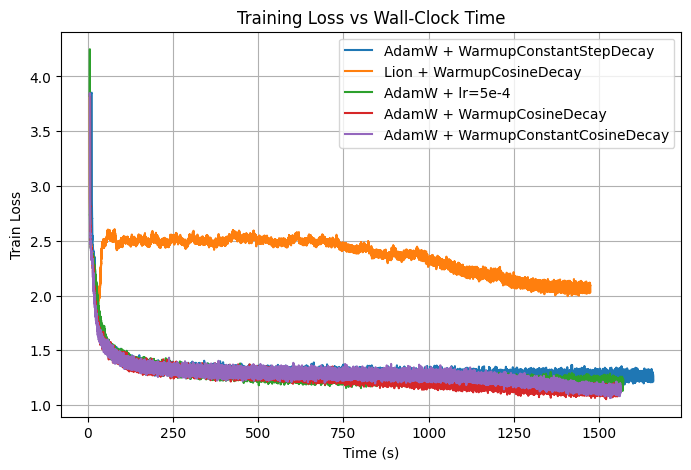

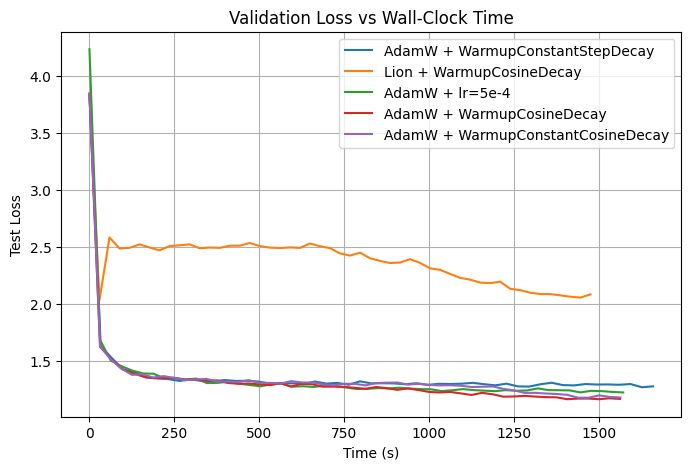

In [8]:
# Plot train loss vs time
plt.figure(figsize=(8,5))
for res in all_results:
    plt.plot(res['train_time_history'], res['train_loss_history'], label=res['Optimizer'])
plt.xlabel("Time (s)")
plt.ylabel("Train Loss")
plt.title("Training Loss vs Wall-Clock Time")
plt.legend()
plt.grid(True)
plt.show()

# Plot test loss vs time
plt.figure(figsize=(8,5))
for res in all_results:
    plt.plot(res['test_time_history'], res['test_loss_history'], label=res['Optimizer'])
plt.xlabel("Time (s)")
plt.ylabel("Test Loss")
plt.title("Validation Loss vs Wall-Clock Time")
plt.legend()
plt.grid(True)
plt.show()

##### summary metrics

In [9]:
from sklearn.metrics import auc

def summarize(res):
    times = np.array(res['test_time_history'])
    losses = np.array(res['test_loss_history'])
    final = float(losses[-1])
    min_loss = float(losses.min())
    # time to 95% of (final-min)
    target = min_loss + 0.05 * (final - min_loss)
    idx95 = np.argmin(np.abs(losses - target))
    t95 = float(times[idx95])
    # area under loss-time curve (normalized by total time)
    total_time = times[-1]
    aulc = auc(times, losses) / total_time
    # early slope (first 20% of time)
    early_mask = times <= 0.2 * total_time
    if early_mask.sum() >= 2:
        p = np.polyfit(times[early_mask], losses[early_mask], 1)
        early_slope = float(p[0])
    else:
        early_slope = np.nan
    return {
        "Optimizer": res['Optimizer'],
        "Final Test Loss": final,
        "Min Test Loss": min_loss,
        "Time to 95% (s)": t95,
        "AULC": aulc,
        "Early Slope": early_slope
    }

df = pd.DataFrame([summarize(r) for r in all_results]).sort_values("Final Test Loss")
print(df)

                           Optimizer  Final Test Loss  Min Test Loss  \
3          AdamW + WarmupCosineDecay         1.165003       1.162398   
4  AdamW + WarmupConstantCosineDecay         1.177516       1.175680   
2                    AdamW + lr=5e-4         1.221992       1.221992   
0    AdamW + WarmupConstantStepDecay         1.275580       1.267349   
1           Lion + WarmupCosineDecay         2.082403       2.032733   

   Time to 95% (s)      AULC  Early Slope  
3      1499.522660  1.298240    -0.004181  
4      1469.329815  1.324881    -0.004184  
2      1571.284381  1.320916    -0.004785  
0      1626.116979  1.344223    -0.003982  
1        29.496387  2.374834    -0.001528  


##### pareto plot

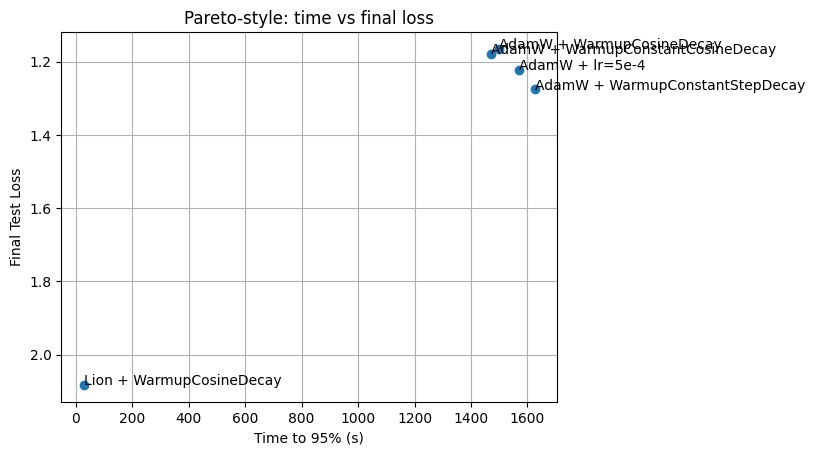

In [10]:
plt.figure()
plt.scatter(df["Time to 95% (s)"], df["Final Test Loss"])
for i, r in df.iterrows():
    plt.text(r["Time to 95% (s)"], r["Final Test Loss"], r["Optimizer"])
plt.xlabel("Time to 95% (s)")
plt.ylabel("Final Test Loss")
plt.title("Pareto-style: time vs final loss")
plt.gca().invert_yaxis() # optional if lower loss is better and you want top-left good
plt.grid(True)
plt.show()